In [1]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt

logging.getLogger("matplotlib").setLevel(logging.ERROR)
plt.style.use('default')

sig_level = 5e-8

wgs_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/snippet_analysis/wgs_vs_array/results/02.assoc_result/wgs/wgs_vs_array.wgs.sex.10pc.additive.PHENO1.glm.logistic"
array_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/snippet_analysis/wgs_vs_array/results/02.assoc_result/array/wgs_vs_array.array.sex.10pc.additive.PHENO1.glm.logistic"

In [2]:
wgs_df = pd.read_csv(wgs_path, sep='\t')
array_df = pd.read_csv(array_path, sep='\t')

STEP 1: Initial Data Extraction
WGS original variants:    293,893
Array original variants:  293,893

STEP 2: Filter Missing or Invalid P-values
WGS variants with invalid P (., NA, inf):         17
Array variants with invalid P (., NA, inf):      137
WGS variants remaining:    293,876
Array variants remaining:  293,756

STEP 3: Filter Missing or Invalid BETA/SE values
WGS variants with invalid BETA/SE (., NA, inf):          0
Array variants with invalid BETA/SE (., NA, inf):        0
WGS variants remaining:    293,876
Array variants remaining:  293,756

STEP 4: Merge Common Variants
Common variants after merge:  293,754

FILTERING SUMMARY

WGS Variants:
  Original:                   293,893
  Removed (invalid P):             17 ( 0.01%)
  Removed (invalid BETA/SE):        0 ( 0.00%)
  Final clean variants:       293,876 (99.99%)

Array Variants:
  Original:                   293,893
  Removed (invalid P):            137 ( 0.05%)
  Removed (invalid BETA/SE):        0 ( 0.00%)
  Final cle

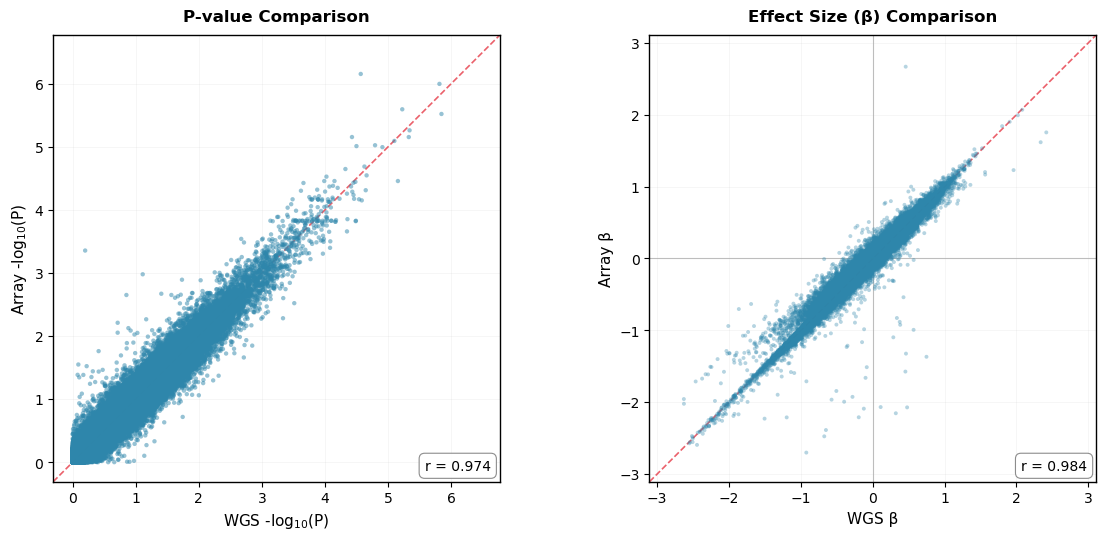


CORRELATION STATISTICS
-log10(P) Pearson correlation: 0.9738
BETA Pearson correlation:      0.9840

TOP 10 SNPS WITH LARGEST P-VALUE DIFFERENCE
              SNPID    P_wgs      P_array  BETA_wgs  BETA_array  neglogP_diff  BETA_diff
 chr13:91480619:G:A 0.631719 4.415430e-04 -0.124495   -2.091160      3.155551   1.966665
 chr20:60519494:C:T 0.077384 1.049660e-03  0.495682    0.931109      1.867601   0.435427
chr12:108303185:G:A 0.140348 2.234810e-03 -0.506711   -1.845220      1.797966   1.338509
  chr6:30255227:G:C 0.000027 7.032850e-07  0.657577    0.799968      1.587204   0.142391
 chr6:110431429:A:G 0.192977 6.155740e-03  0.441312    0.745998      1.496225   0.304686
   chr10:955880:C:T 0.810122 2.821500e-02 -0.100558   -1.662030      1.458070   1.561472
  chr2:62508571:A:G 0.386743 1.732260e-02 -0.097352   -0.259880      1.348809   0.162528
 chr2:219315286:T:C 0.193070 8.834730e-03  0.458365    2.668770      1.339522   2.210405
 chr19:41250180:T:C 0.831761 4.110470e-02 -0.083569   

In [3]:
# ========== Step 1: Extract initial data ==========
print("=" * 70)
print("STEP 1: Initial Data Extraction")
print("=" * 70)

# Extract P, BETA, SE and SNPID from both datasets
wgs_data = wgs_df[['ID', 'P', 'BETA', 'SE']].copy()
array_data = array_df[['ID', 'P', 'BETA', 'SE']].copy()

# Rename columns for clarity
wgs_data.columns = ['SNPID', 'P_wgs', 'BETA_wgs', 'SE_wgs']
array_data.columns = ['SNPID', 'P_array', 'BETA_array', 'SE_array']

# Count original variants
wgs_original = len(wgs_data)
array_original = len(array_data)

print(f"WGS original variants:   {wgs_original:>8,}")
print(f"Array original variants: {array_original:>8,}")

# ========== Step 2: Remove missing P-values ==========
print("\n" + "=" * 70)
print("STEP 2: Filter Missing or Invalid P-values")
print("=" * 70)

# Mark rows with '.' or NaN in P column
wgs_data['P_wgs'] = wgs_data['P_wgs'].replace('.', np.nan)
array_data['P_array'] = array_data['P_array'].replace('.', np.nan)

# Convert P to numeric
wgs_data['P_wgs'] = pd.to_numeric(wgs_data['P_wgs'], errors='coerce')
array_data['P_array'] = pd.to_numeric(array_data['P_array'], errors='coerce')

# Count variants with invalid P (NaN or inf)
wgs_p_invalid = wgs_data['P_wgs'].isna() | np.isinf(wgs_data['P_wgs'])
array_p_invalid = array_data['P_array'].isna() | np.isinf(array_data['P_array'])

wgs_p_removed = wgs_p_invalid.sum()
array_p_removed = array_p_invalid.sum()

print(f"WGS variants with invalid P (., NA, inf):   {wgs_p_removed:>8,}")
print(f"Array variants with invalid P (., NA, inf): {array_p_removed:>8,}")

# Remove these variants
wgs_data = wgs_data[~wgs_p_invalid].copy()
array_data = array_data[~array_p_invalid].copy()

wgs_after_p = len(wgs_data)
array_after_p = len(array_data)

print(f"WGS variants remaining:   {wgs_after_p:>8,}")
print(f"Array variants remaining: {array_after_p:>8,}")

# ========== Step 3: Remove missing BETA/SE values ==========
print("\n" + "=" * 70)
print("STEP 3: Filter Missing or Invalid BETA/SE values")
print("=" * 70)

# Replace '.' with NaN and convert to numeric
for col in ['BETA_wgs', 'SE_wgs']:
    wgs_data[col] = wgs_data[col].replace('.', np.nan)
    wgs_data[col] = pd.to_numeric(wgs_data[col], errors='coerce')

for col in ['BETA_array', 'SE_array']:
    array_data[col] = array_data[col].replace('.', np.nan)
    array_data[col] = pd.to_numeric(array_data[col], errors='coerce')

# Count variants with invalid BETA or SE (NaN or inf)
wgs_beta_se_invalid = (
    wgs_data['BETA_wgs'].isna() | np.isinf(wgs_data['BETA_wgs']) |
    wgs_data['SE_wgs'].isna() | np.isinf(wgs_data['SE_wgs'])
)

array_beta_se_invalid = (
    array_data['BETA_array'].isna() | np.isinf(array_data['BETA_array']) |
    array_data['SE_array'].isna() | np.isinf(array_data['SE_array'])
)

wgs_beta_se_removed = wgs_beta_se_invalid.sum()
array_beta_se_removed = array_beta_se_invalid.sum()

print(f"WGS variants with invalid BETA/SE (., NA, inf):   {wgs_beta_se_removed:>8,}")
print(f"Array variants with invalid BETA/SE (., NA, inf): {array_beta_se_removed:>8,}")

# Remove these variants
wgs_data = wgs_data[~wgs_beta_se_invalid].copy()
array_data = array_data[~array_beta_se_invalid].copy()

wgs_final = len(wgs_data)
array_final = len(array_data)

print(f"WGS variants remaining:   {wgs_final:>8,}")
print(f"Array variants remaining: {array_final:>8,}")

# ========== Step 4: Merge and finalize ==========
print("\n" + "=" * 70)
print("STEP 4: Merge Common Variants")
print("=" * 70)

# Merge on common SNPIDs
merged_data = pd.merge(wgs_data, array_data, on='SNPID', how='inner')

# Calculate -log10(P) for both datasets
merged_data['neglog10P_wgs'] = -np.log10(merged_data['P_wgs'])
merged_data['neglog10P_array'] = -np.log10(merged_data['P_array'])

# Check for any remaining infinite values after -log10 transformation
inf_check = (
    np.isinf(merged_data['neglog10P_wgs']) | 
    np.isinf(merged_data['neglog10P_array'])
)
inf_removed = inf_check.sum()

if inf_removed > 0:
    print(f"Variants with inf after -log10(P) transformation: {inf_removed:>8,}")
    merged_data = merged_data[~inf_check].copy()

common_variants = len(merged_data)

print(f"Common variants after merge: {common_variants:>8,}")

# ========== Summary Statistics ==========
print("\n" + "=" * 70)
print("FILTERING SUMMARY")
print("=" * 70)

print("\nWGS Variants:")
print(f"  Original:                  {wgs_original:>8,}")
print(f"  Removed (invalid P):       {wgs_p_removed:>8,} ({wgs_p_removed/wgs_original*100:>5.2f}%)")
print(f"  Removed (invalid BETA/SE): {wgs_beta_se_removed:>8,} ({wgs_beta_se_removed/wgs_after_p*100:>5.2f}%)")
print(f"  Final clean variants:      {wgs_final:>8,} ({wgs_final/wgs_original*100:>5.2f}%)")

print("\nArray Variants:")
print(f"  Original:                  {array_original:>8,}")
print(f"  Removed (invalid P):       {array_p_removed:>8,} ({array_p_removed/array_original*100:>5.2f}%)")
print(f"  Removed (invalid BETA/SE): {array_beta_se_removed:>8,} ({array_beta_se_removed/array_after_p*100:>5.2f}%)")
print(f"  Final clean variants:      {array_final:>8,} ({array_final/array_original*100:>5.2f}%)")

print("\nCommon Variants:")
print(f"  Overlapping variants:      {common_variants:>8,}")
print(f"  WGS coverage:              {common_variants/wgs_final*100:>5.2f}% of clean WGS variants")
print(f"  Array coverage:            {common_variants/array_final*100:>5.2f}% of clean Array variants")

print("\n" + "=" * 70)
print("DATA RANGES")
print("=" * 70)
print(f"P-value range (WGS):   {merged_data['P_wgs'].min():.2e} - {merged_data['P_wgs'].max():.2e}")
print(f"P-value range (Array): {merged_data['P_array'].min():.2e} - {merged_data['P_array'].max():.2e}")
print(f"BETA range (WGS):      {merged_data['BETA_wgs'].min():>7.4f} - {merged_data['BETA_wgs'].max():>7.4f}")
print(f"BETA range (Array):    {merged_data['BETA_array'].min():>7.4f} - {merged_data['BETA_array'].max():>7.4f}")

# ========== Visualization ==========
print("\n" + "=" * 70)
print("GENERATING PLOTS")
print("=" * 70)

# Set publication-quality figure parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# ========== Left panel: -log10(P) comparison ==========
# Determine data range for P-value plot
max_val_p = max(merged_data['neglog10P_wgs'].max(), merged_data['neglog10P_array'].max())
min_val_p = 0

# Add padding to axis limits (10% buffer)
padding_p = max_val_p * 0.1
limit_p = max_val_p + padding_p

# Plot scatter with better color
ax1.scatter(merged_data['neglog10P_wgs'], merged_data['neglog10P_array'], 
           alpha=0.5, s=10, c='#2E86AB', edgecolors='none', rasterized=True, zorder=3)

# Set axis limits with padding
ax1.set_xlim(min_val_p - padding_p * 0.5, limit_p)
ax1.set_ylim(min_val_p - padding_p * 0.5, limit_p)

# Add diagonal reference line covering the entire visible range
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
diag_min = max(xlim[0], ylim[0])
diag_max = min(xlim[1], ylim[1])
ax1.plot([diag_min, diag_max], [diag_min, diag_max], 
        color='#E63946', linestyle='--', lw=1.2, alpha=0.8, zorder=2)

# Add significance threshold lines
sig_threshold = -np.log10(sig_level)
ax1.axhline(y=sig_threshold, color='gray', linestyle=':', alpha=0.6, linewidth=1, zorder=1)
ax1.axvline(x=sig_threshold, color='gray', linestyle=':', alpha=0.6, linewidth=1, zorder=1)

# Labels and formatting
ax1.set_xlabel('WGS -log$_{10}$(P)', fontsize=11)
ax1.set_ylabel('Array -log$_{10}$(P)', fontsize=11)
ax1.set_title('P-value Comparison', fontsize=12, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.15, linestyle='-', linewidth=0.5, zorder=0)
ax1.tick_params(axis='both', which='major', labelsize=10)

# Calculate correlation
corr_p = np.corrcoef(merged_data['neglog10P_wgs'], merged_data['neglog10P_array'])[0, 1]
ax1.text(0.98, 0.02, f'r = {corr_p:.3f}', 
        transform=ax1.transAxes, fontsize=10, 
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                  edgecolor='gray', linewidth=0.8, alpha=0.9))

# ========== Right panel: BETA comparison ==========
# Determine data range
max_val_beta = max(abs(merged_data['BETA_wgs']).max(), abs(merged_data['BETA_array']).max())

# Add padding to axis limits (15% buffer)
padding_beta = max_val_beta * 0.15
limit_beta = max_val_beta + padding_beta
min_val_beta = -(max_val_beta + padding_beta)

# Plot scatter without error bars for cleaner appearance
ax2.scatter(merged_data['BETA_wgs'], merged_data['BETA_array'],
           alpha=0.35, s=8, c='#2E86AB', edgecolors='none', rasterized=True, zorder=3)

# Set axis limits with padding
ax2.set_xlim(min_val_beta, limit_beta)
ax2.set_ylim(min_val_beta, limit_beta)

# Add diagonal reference line covering the entire visible range
xlim = ax2.get_xlim()
ylim = ax2.get_ylim()
diag_min = max(xlim[0], ylim[0])
diag_max = min(xlim[1], ylim[1])
ax2.plot([diag_min, diag_max], [diag_min, diag_max], 
        color='#E63946', linestyle='--', lw=1.2, alpha=0.8, zorder=2)

# Add zero lines
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.25, linewidth=0.8, zorder=1)
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.25, linewidth=0.8, zorder=1)

# Labels and formatting
ax2.set_xlabel('WGS β', fontsize=11)
ax2.set_ylabel('Array β', fontsize=11)
ax2.set_title('Effect Size (β) Comparison', fontsize=12, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.15, linestyle='-', linewidth=0.5, zorder=0)
ax2.tick_params(axis='both', which='major', labelsize=10)

# Calculate correlation
corr_beta = np.corrcoef(merged_data['BETA_wgs'], merged_data['BETA_array'])[0, 1]
ax2.text(0.98, 0.02, f'r = {corr_beta:.3f}', 
        transform=ax2.transAxes, fontsize=10, 
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                  edgecolor='gray', linewidth=0.8, alpha=0.9))

# Set equal aspect ratio
ax1.set_aspect('equal', adjustable='box')
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
# plt.savefig('wgs_array_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('wgs_array_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Reset matplotlib parameters
plt.rcParams.update(plt.rcParamsDefault)

# ========== Correlation Statistics ==========
print("\n" + "=" * 70)
print("CORRELATION STATISTICS")
print("=" * 70)
print(f"-log10(P) Pearson correlation: {corr_p:.4f}")
print(f"BETA Pearson correlation:      {corr_beta:.4f}")

# ========== Top Discordant SNPs ==========
print("\n" + "=" * 70)
print("TOP 10 SNPS WITH LARGEST P-VALUE DIFFERENCE")
print("=" * 70)

merged_data['neglogP_diff'] = np.abs(merged_data['neglog10P_wgs'] - merged_data['neglog10P_array'])
merged_data['BETA_diff'] = np.abs(merged_data['BETA_wgs'] - merged_data['BETA_array'])

top_discordant = merged_data.nlargest(10, 'neglogP_diff')[['SNPID', 'P_wgs', 'P_array', 'BETA_wgs', 'BETA_array', 'neglogP_diff', 'BETA_diff']]
print(top_discordant.to_string(index=False))

In [4]:
array_vqc_sum = '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/array_rev1/results/09.variant_qc_stats/cteph_agp3k.ajsa.sqc.norm.biallelic.vmiss_qc.autosomes.variant_qc_sum.tsv'

Array QC columns: ['VARIANT_ID', 'AAF_ALL', 'AAF_CASE', 'AAF_CTRL', 'MAF_ALL', 'MAF_CASE', 'MAF_CTRL', 'HWE_ALL', 'HWE_CASE', 'HWE_CTRL']
Array QC shape: (535182, 10)

SNPs with MAF data: 293,754 / 293,754
MAF range: 0.0100 - 0.5000

GENERATING MAF-COLORED PLOTS


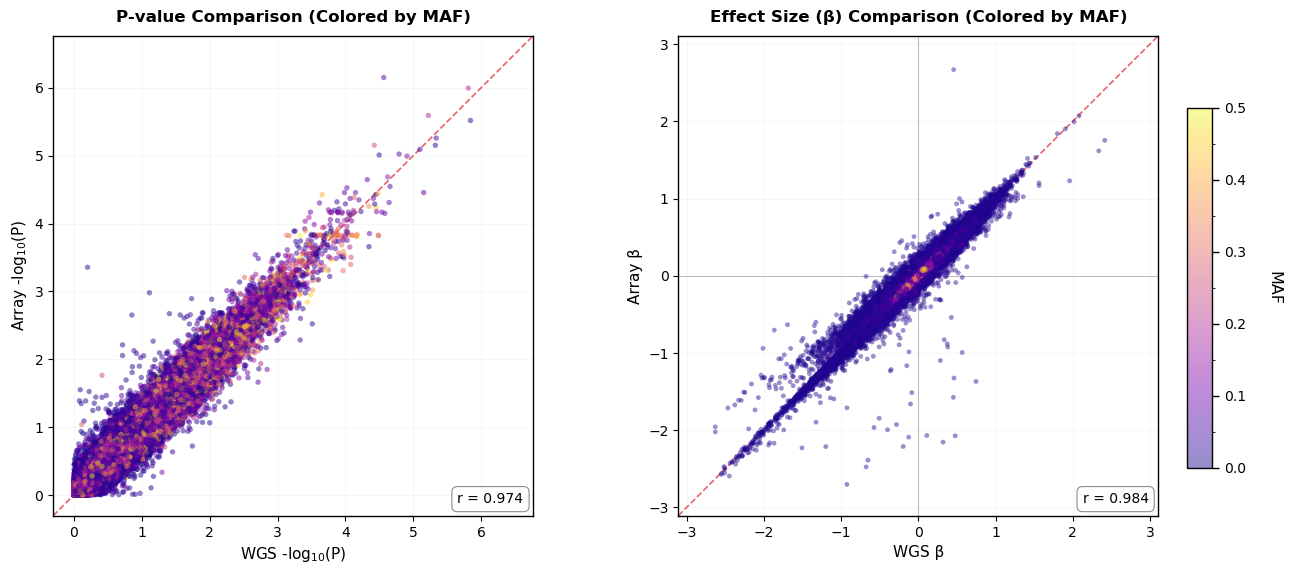


Plot generation complete!


In [6]:
# Load array QC summary data
array_vqc = pd.read_csv(array_vqc_sum, sep='\t')

# Check column names to identify the SNPID column
print("Array QC columns:", array_vqc.columns.tolist())
print(f"Array QC shape: {array_vqc.shape}")

# Merge with MAF data - check if column is 'SNPID' or 'VARIANT_ID'
if 'VARIANT_ID' in array_vqc.columns:
    array_vqc_subset = array_vqc[['VARIANT_ID', 'MAF_ALL']].copy()
    array_vqc_subset.columns = ['SNPID', 'MAF_ALL']
elif 'SNPID' in array_vqc.columns:
    array_vqc_subset = array_vqc[['SNPID', 'MAF_ALL']].copy()
else:
    print("Available columns:", array_vqc.columns.tolist())
    array_vqc_subset = array_vqc.iloc[:, [0]].copy()  # Take first column as SNPID
    array_vqc_subset['MAF_ALL'] = array_vqc['MAF_ALL']
    array_vqc_subset.columns = ['SNPID', 'MAF_ALL']

# Merge MAF data with merged_data
merged_with_maf = pd.merge(merged_data, array_vqc_subset, on='SNPID', how='left')

# Check how many SNPs have MAF data
print(f"\nSNPs with MAF data: {merged_with_maf['MAF_ALL'].notna().sum():,} / {len(merged_with_maf):,}")
print(f"MAF range: {merged_with_maf['MAF_ALL'].min():.4f} - {merged_with_maf['MAF_ALL'].max():.4f}")

# ========== Visualization with MAF coloring ==========
print("\n" + "=" * 70)
print("GENERATING MAF-COLORED PLOTS")
print("=" * 70)

# Set publication-quality figure parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1

# Create figure with two subplots and extra space for colorbar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== Left panel: -log10(P) comparison with MAF coloring ==========
# Determine data range for P-value plot
max_val_p = max(merged_with_maf['neglog10P_wgs'].max(), merged_with_maf['neglog10P_array'].max())
min_val_p = 0
padding_p = max_val_p * 0.1
limit_p = max_val_p + padding_p

# Create scatter plot with MAF coloring using plasma colormap
scatter1 = ax1.scatter(merged_with_maf['neglog10P_wgs'], merged_with_maf['neglog10P_array'], 
           c=merged_with_maf['MAF_ALL'], cmap='plasma', 
           alpha=0.5, s=15, edgecolors='none', rasterized=True, zorder=3,
           vmin=0, vmax=0.5)

# Set axis limits with padding
ax1.set_xlim(min_val_p - padding_p * 0.5, limit_p)
ax1.set_ylim(min_val_p - padding_p * 0.5, limit_p)

# Add diagonal reference line
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
diag_min = max(xlim[0], ylim[0])
diag_max = min(xlim[1], ylim[1])
ax1.plot([diag_min, diag_max], [diag_min, diag_max], 
        color='#E63946', linestyle='--', lw=1.2, alpha=0.8, zorder=2)

# Add significance threshold lines
sig_threshold = -np.log10(sig_level)
ax1.axhline(y=sig_threshold, color='gray', linestyle=':', alpha=0.6, linewidth=1, zorder=1)
ax1.axvline(x=sig_threshold, color='gray', linestyle=':', alpha=0.6, linewidth=1, zorder=1)

# Labels and formatting
ax1.set_xlabel('WGS -log$_{10}$(P)', fontsize=11)
ax1.set_ylabel('Array -log$_{10}$(P)', fontsize=11)
ax1.set_title('P-value Comparison (Colored by MAF)', fontsize=12, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.15, linestyle='-', linewidth=0.5, zorder=0)
ax1.tick_params(axis='both', which='major', labelsize=10)

# Calculate correlation
corr_p = np.corrcoef(merged_with_maf['neglog10P_wgs'], merged_with_maf['neglog10P_array'])[0, 1]
ax1.text(0.98, 0.02, f'r = {corr_p:.3f}', 
        transform=ax1.transAxes, fontsize=10, 
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                  edgecolor='gray', linewidth=0.8, alpha=0.9))

# ========== Right panel: BETA comparison with MAF coloring ==========
# Determine data range
max_val_beta = max(abs(merged_with_maf['BETA_wgs']).max(), abs(merged_with_maf['BETA_array']).max())
padding_beta = max_val_beta * 0.15
limit_beta = max_val_beta + padding_beta
min_val_beta = -(max_val_beta + padding_beta)

# Plot scatter with MAF coloring using plasma colormap
scatter2 = ax2.scatter(merged_with_maf['BETA_wgs'], merged_with_maf['BETA_array'],
           c=merged_with_maf['MAF_ALL'], cmap='plasma',
           alpha=0.45, s=12, edgecolors='none', rasterized=True, zorder=3,
           vmin=0, vmax=0.5)

# Set axis limits with padding
ax2.set_xlim(min_val_beta, limit_beta)
ax2.set_ylim(min_val_beta, limit_beta)

# Add diagonal reference line
xlim = ax2.get_xlim()
ylim = ax2.get_ylim()
diag_min = max(xlim[0], ylim[0])
diag_max = min(xlim[1], ylim[1])
ax2.plot([diag_min, diag_max], [diag_min, diag_max], 
        color='#E63946', linestyle='--', lw=1.2, alpha=0.8, zorder=2)

# Add zero lines
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.25, linewidth=0.8, zorder=1)
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.25, linewidth=0.8, zorder=1)

# Labels and formatting
ax2.set_xlabel('WGS β', fontsize=11)
ax2.set_ylabel('Array β', fontsize=11)
ax2.set_title('Effect Size (β) Comparison (Colored by MAF)', fontsize=12, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.15, linestyle='-', linewidth=0.5, zorder=0)
ax2.tick_params(axis='both', which='major', labelsize=10)

# Calculate correlation
corr_beta = np.corrcoef(merged_with_maf['BETA_wgs'], merged_with_maf['BETA_array'])[0, 1]
ax2.text(0.98, 0.02, f'r = {corr_beta:.3f}', 
        transform=ax2.transAxes, fontsize=10, 
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                  edgecolor='gray', linewidth=0.8, alpha=0.9))

# Set equal aspect ratio
ax1.set_aspect('equal', adjustable='box')
ax2.set_aspect('equal', adjustable='box')

# Adjust subplot positions to make room for colorbar
plt.subplots_adjust(left=0.07, right=0.86, bottom=0.12, top=0.92, wspace=0.30)

# Add colorbar on the right side with improved configuration
cbar_ax = fig.add_axes([0.88, 0.20, 0.018, 0.60])
cbar = fig.colorbar(scatter2, cax=cbar_ax)
cbar.set_label('MAF', fontsize=11.5, labelpad=15, rotation=270, va='bottom')
cbar.ax.tick_params(labelsize=10, length=5, width=1)
cbar.outline.set_linewidth(1)

# Set reasonable colorbar ticks with better granularity
import matplotlib.ticker as ticker
cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
cbar.ax.set_yticklabels(['0.0', '0.1', '0.2', '0.3', '0.4', '0.5'])
cbar.ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))

# plt.savefig('wgs_array_comparison_maf.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('wgs_array_comparison_maf.png', dpi=300, bbox_inches='tight')
plt.show()

# Reset matplotlib parameters
plt.rcParams.update(plt.rcParamsDefault)

print("\nPlot generation complete!")